## 1. Load the Feature Engineered Data

In [11]:
import pandas as pd

df = pd.read_csv("../data/processed/netflix_feature_engineered.csv")

print(df.shape)
df.head()

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [12]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

## 2. Select Modeling Features

In [13]:
df['duration_int'] = df['duration'].str.extract('(\d+)')
df['duration_int'] = df['duration_int'].astype(float)
df['primary_country'] = df['country'].str.split(',').str[0]
df['primary_country'] = df['primary_country'].fillna("Unknown")
df['main_genre'] = df['listed_in'].str.split(',').str[0]
def length_category(x):
    if x < 60:
        return "Short"
    elif x < 120:
        return "Medium"
    else:
        return "Long"

df['content_length_category'] = df['duration_int'].apply(length_category)
df['is_original'] = df['description'].str.contains(
    "Netflix", case=False, na=False
)
df['is_original'] = df['is_original'].astype(int)


In [14]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'duration_int', 'primary_country', 'main_genre',
       'content_length_category', 'is_original'],
      dtype='object')

## 3. Convert Categorical → Numerical

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['type_encoded'] = le.fit_transform(df['type'])
df['rating_encoded'] = le.fit_transform(df['rating'])
df['country_encoded'] = le.fit_transform(df['primary_country'])
df['genre_encoded'] = le.fit_transform(df['main_genre'])
df['length_encoded'] = le.fit_transform(df['content_length_category'])

## 4. Select Final Modeling Dataset

In [16]:
model_df = df[[
    'release_year',
    'duration_int',
    'rating_encoded',
    'country_encoded',
    'genre_encoded',
    'length_encoded',
    'type_encoded'
]]

model_df.head()

,release_year,duration_int,rating_encoded,country_encoded,genre_encoded,length_encoded,type_encoded
0,2020,90.0,7,80,10,1,0
1,2021,2.0,11,67,16,2,1
2,2021,1.0,11,81,8,2,1
3,2021,1.0,11,81,11,2,1
4,2021,2.0,11,30,16,2,1


## Save Modeling Dataset

In [17]:
model_df.to_csv("../data/processed/netflix_modeling_data.csv", index=False)

# Clustering Analysis


### 1. Load Data


In [18]:
df = pd.read_csv("../data/processed/netflix_modeling_data.csv")

### 2. Select Clustering Features

In [19]:
X = df[['duration_int','rating_encoded','genre_encoded']]

### 3. Standardize Data

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 4. Find Optimal Clusters (Elbow Method)

In [22]:
model_df.isnull().sum()

release_year       0
duration_int       3
rating_encoded     0
country_encoded    0
genre_encoded      0
length_encoded     0
type_encoded       0
dtype: int64

In [23]:
model_df = model_df.dropna()

In [24]:
X = model_df

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

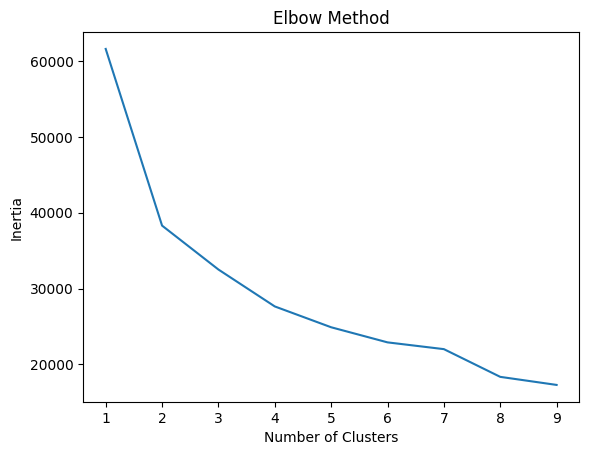

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### 5. Train Clustering Model

In [28]:
kmeans = KMeans(n_clusters=4, random_state=42)

model_df['cluster'] = kmeans.fit_predict(X_scaled)

model_df.head()

,release_year,duration_int,rating_encoded,country_encoded,genre_encoded,length_encoded,type_encoded,cluster
0,2020,90.0,7,80,10,1,0,2
1,2021,2.0,11,67,16,2,1,1
2,2021,1.0,11,81,8,2,1,1
3,2021,1.0,11,81,11,2,1,1
4,2021,2.0,11,30,16,2,1,1


### 6. Cluster Insights

In [30]:
cluster_summary = model_df.groupby('cluster').mean()

print(cluster_summary)

         release_year  duration_int  rating_encoded  country_encoded  \
cluster                                                                
0         2015.073853    109.270183       10.011468        26.505046   
1         2016.746637      1.803438       10.886398        62.194320   
2         2016.962735     86.291971       10.508260        77.231656   
3         2002.240892    109.501115        7.371747        72.574721   

         genre_encoded  length_encoded  type_encoded  
cluster                                               
0             8.741284        0.710092      0.000000  
1            14.137519        2.000000      0.997758  
2            11.626201        1.094506      0.000000  
3             6.365799        0.736803      0.004461  


# Classification Model


### 1. Prepare Data

In [31]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['type_encoded'])
y = df['type_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 2. Train Model (Random Forest)

In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 3. Predictions

In [33]:
y_pred = model.predict(X_test)

### 4. Evaluation

In [34]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



# Advanced Analytics (Feature Importance)

### 1. Feature Importance

In [35]:
import pandas as pd

importance = model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importance
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print(importance_df)

           feature  importance
1     duration_int    0.548555
5   length_encoded    0.319688
4    genre_encoded    0.106801
2   rating_encoded    0.015401
0     release_year    0.005145
3  country_encoded    0.004409


### 2. Plot Feature Importance

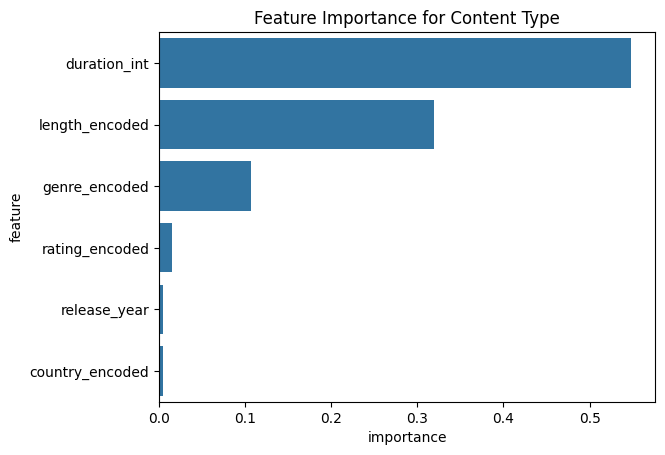

In [36]:
import seaborn as sns

sns.barplot(
    data=importance_df,
    x='importance',
    y='feature'
)

plt.title("Feature Importance for Content Type")
plt.show()

### 3.Correlation Analysis

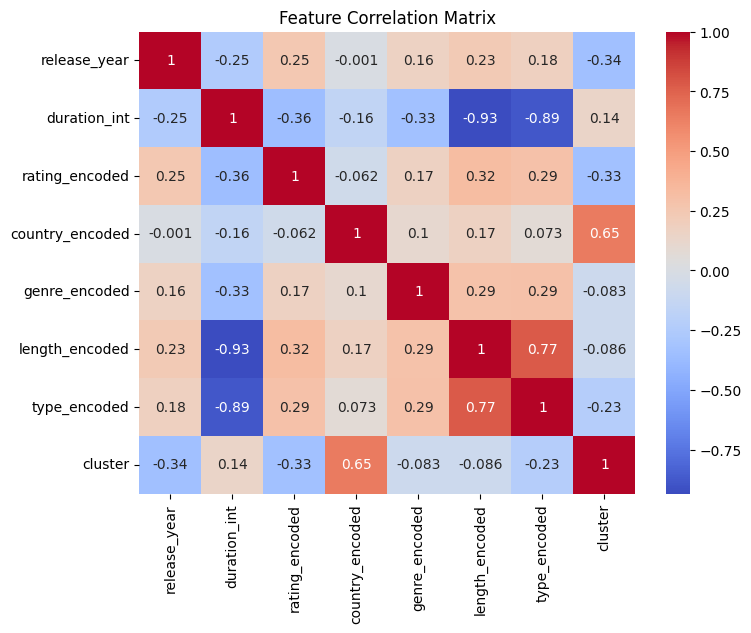

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(
    model_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

### 4. Country vs Genre Analysis

In [43]:
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   release_year     8807 non-null   int64  
 1   duration_int     8804 non-null   float64
 2   rating_encoded   8807 non-null   int64  
 3   country_encoded  8807 non-null   int64  
 4   genre_encoded    8807 non-null   int64  
 5   length_encoded   8807 non-null   int64  
 6   type_encoded     8807 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 481.8 KB


In [42]:
country_genre = pd.crosstab(
    df['country_encoded'],
    df['genre_encoded']
)

country_genre.head()

genre_encoded,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
country_encoded,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,2,1,1,9,7,0,...,0,8,0,0,0,0,0,0,0,0
2,8,0,0,2,14,0,3,3,7,0,...,0,3,0,0,3,1,0,0,0,1
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


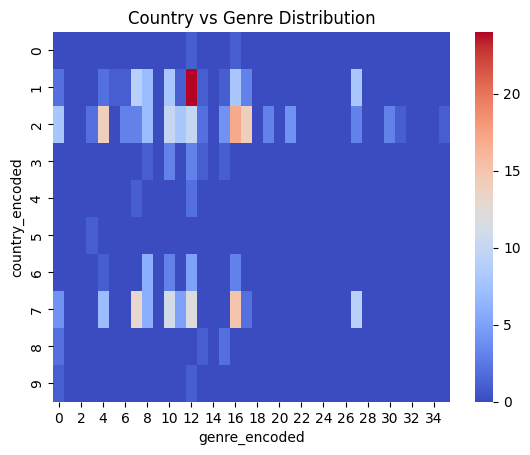

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(country_genre.head(10), cmap="coolwarm")

plt.title("Country vs Genre Distribution")
plt.show()

#### 5. PCA Visualization (Advanced Machine Learning)

In [48]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
model_df = model_df.dropna()
X = model_df.drop(columns=['cluster'], errors='ignore')

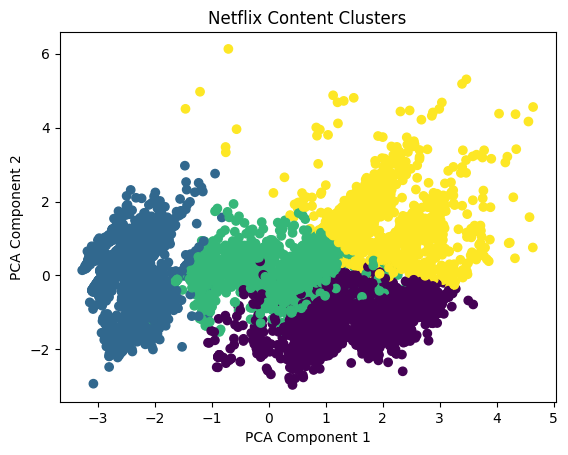

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1], c=model_df['cluster'])

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Netflix Content Clusters")

plt.show()

### 6.Regression Analysis (Extra Advanced)

In [54]:
from sklearn.linear_model import LinearRegression

X_reg = model_df.drop(columns=['duration_int'])
y_reg = model_df['duration_int']

model_reg = LinearRegression()

model_reg.fit(X_reg, y_reg)

pred = model_reg.predict(X_reg)

In [55]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_reg, pred))

R2 Score: 0.9417119208293709
